## Weather Summary Classification Project

IN this project, I worked on Classifyning wather conditions based on different environmental features like temperature, humidity, wind speed, and pressure.
The main goal is to predict the weather summary (such as sunny, rainy, cloudy, etc.) using Machine Learning Algorithms. This project helped me understand how classification models work on real- world datasets.
Initially, I was not sure which model would perform best, so i tried multiple algorithms and compared their results

In [37]:
# Import Libraries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder, StandardScaler 
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

The dataset contains weather-related information with multiple features such as:
- Temperature: Indicates how hot or cold the environment is 
- Humidity: Represents the amount of moisture in the air
- Wind Speed: Speed of wind flow
- Pressure: Atomospheric pressure level

Taregt Variable: 
- Weather Summary (output we are prediciting)

While exploring the dataset. I noticed that some feature like temperature and humidity seem to have more impact on weather conditions 

In [38]:
# Load Dataset 
df = pd.read_csv("weatherHistory.csv") 

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (96453, 11)
                  Formatted Date        Summary Precip Type  Temperature (C)  \
0  2006-04-01 00:00:00.000 +0200  Partly Cloudy        rain         9.472222   
1  2006-04-01 01:00:00.000 +0200  Partly Cloudy        rain         9.355556   
2  2006-04-01 02:00:00.000 +0200  Mostly Cloudy        rain         9.377778   
3  2006-04-01 03:00:00.000 +0200  Partly Cloudy        rain         8.288889   
4  2006-04-01 04:00:00.000 +0200  Mostly Cloudy        rain         8.755556   

   Apparent Temperature (C)  Humidity  Wind Speed (km/h)  \
0                  7.388889      0.89            14.1197   
1                  7.227778      0.86            14.2646   
2                  9.377778      0.89             3.9284   
3                  5.944444      0.83            14.1036   
4                  6.977778      0.83            11.0446   

   Wind Bearing (degrees)  Visibility (km)  Pressure (millibars)  \
0                     251          15.8263               1015.1

In [39]:
# Data Cleaning 
# Convert data column 
df['Formatted Date'] = pd.to_datetime(df['Formatted Date'], utc=True)

# Handle Missing values
df.fillna(method='ffill', inplace= True)

# Drop unnecessary Values
df.drop(['Formatted Date'], axis=1, inplace=True)


C:\Users\HP\AppData\Local\Temp\ipykernel_9904\4292218990.py:6: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace= True)


In [40]:
# Simplify Target

def simplify_weather(x):
    x = str(x).lower()
    if "rain" in x:
        return "Rainy"
    elif "cloud" in x:
        return "Cloudy"
    else:
        return "Clear"

df['Daily Summary'] = df['Daily Summary'].apply(simplify_weather)

print(df['Daily Summary'].value_counts())


Daily Summary
Cloudy    72519
Clear     23742
Rainy       192
Name: count, dtype: int64


In [41]:
from nbformat.v4 import new_notebook, new_markdown_cell, new_code_cell

cells = []

def md(text):
    return new_markdown_cell(text)

def code(text):
    return new_code_cell(text)

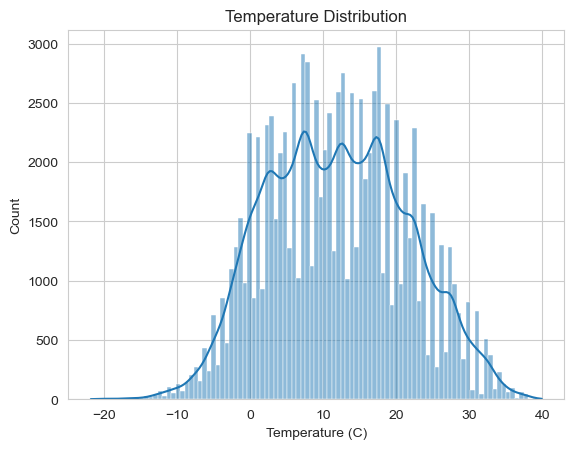

In [42]:
# EDA (Exploratory Data Analysis)
# Distribution Plot
plt.figure()
sns.histplot(df['Temperature (C)'], kde=True)
plt.title("Temperature Distribution")
plt.show()  



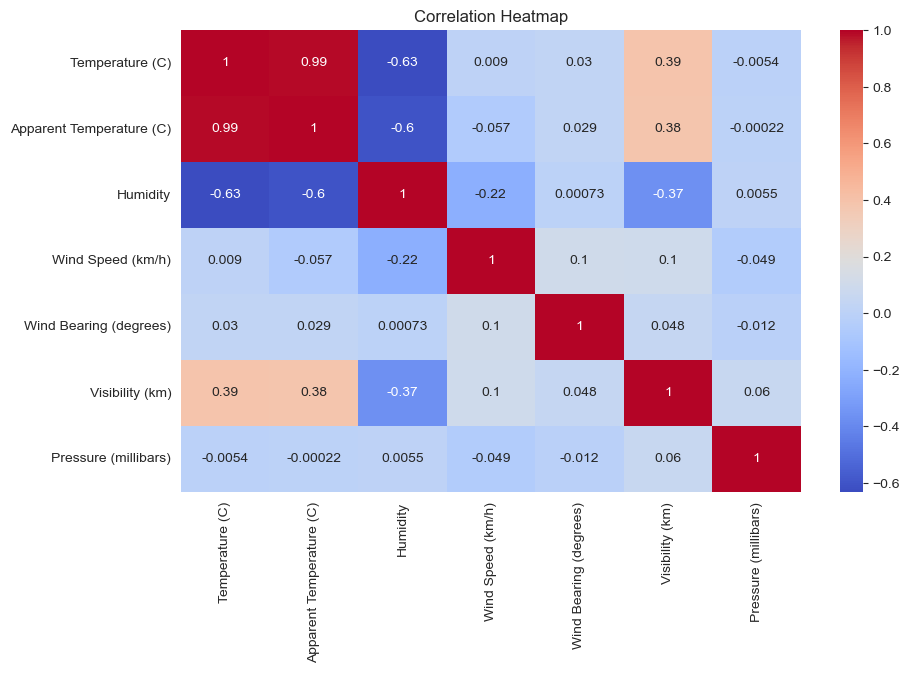

In [43]:
# Correlation Heatmap 
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

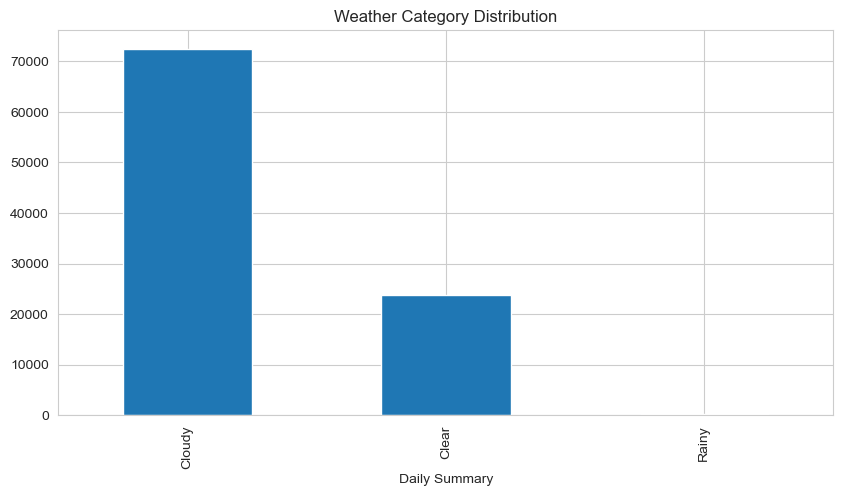

In [44]:
plt.figure(figsize=(10,5))
df['Daily Summary'].value_counts().plot(kind='bar')
plt.title("Weather Category Distribution")
plt.show()

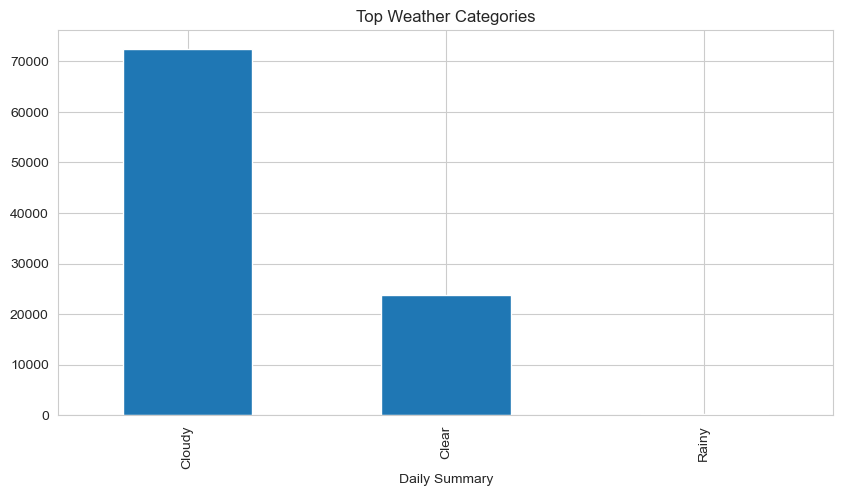

In [45]:
# Traget distribution

plt.figure(figsize=(10,5))
df['Daily Summary'].value_counts().head(10).plot(kind='bar')
plt.title("Top Weather Categories")
plt.show()

In [46]:
# Encode Categorical Data 

from sklearn.preprocessing import LabelEncoder

le_precip = LabelEncoder()
le_summary = LabelEncoder()
le_daily = LabelEncoder()

df['Precip Type'] = le_precip.fit_transform(df['Precip Type'])
df['Summary'] = le_summary.fit_transform(df['Summary'])
df['Daily Summary'] = le_daily.fit_transform(df['Daily Summary'])

In [47]:
print(df['Daily Summary'].value_counts())

Daily Summary
1    72519
0    23742
2      192
Name: count, dtype: int64


In [48]:
# Feature & Traget Split 
X = df.drop('Daily Summary', axis=1)
y = df['Daily Summary']

In [49]:
print(X.head())
print(y.head())

   Summary  Precip Type  Temperature (C)  Apparent Temperature (C)  Humidity  \
0       19            0         9.472222                  7.388889      0.89   
1       19            0         9.355556                  7.227778      0.86   
2       17            0         9.377778                  9.377778      0.89   
3       19            0         8.288889                  5.944444      0.83   
4       17            0         8.755556                  6.977778      0.83   

   Wind Speed (km/h)  Wind Bearing (degrees)  Visibility (km)  \
0            14.1197                     251          15.8263   
1            14.2646                     259          15.8263   
2             3.9284                     204          14.9569   
3            14.1036                     269          15.8263   
4            11.0446                     259          15.8263   

   Pressure (millibars)  
0               1015.13  
1               1015.63  
2               1015.94  
3               1016.41 

In [50]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (96453, 9)
y shape: (96453,)


In [51]:
display(X.head())
display(y.head())

,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars)
0,19,0,9.472222,7.388889,0.89,14.1197,251,15.8263,1015.13
1,19,0,9.355556,7.227778,0.86,14.2646,259,15.8263,1015.63
2,17,0,9.377778,9.377778,0.89,3.9284,204,14.9569,1015.94
3,19,0,8.288889,5.944444,0.83,14.1036,269,15.8263,1016.41
4,17,0,8.755556,6.977778,0.83,11.0446,259,15.8263,1016.51


0    1
1    1
2    1
3    1
4    1
Name: Daily Summary, dtype: int64

In [52]:
# Feature Scaling 
Scaler = StandardScaler()
X_scaled = Scaler.fit_transform(X)  

In [53]:
print(X_scaled[:5])   # first 5 rows

[[ 0.68645963 -0.3534606  -0.25759902 -0.32403547  0.79347043  0.47863499
   0.591256    1.30697578  0.10168518]
 [ 0.68645963 -0.3534606  -0.26981351 -0.3390971   0.63999555  0.49959388
   0.66575578  1.30697578  0.1059598 ]
 [ 0.22789914 -0.3534606  -0.26748694 -0.13810226  0.79347043 -0.99547337
   0.15356981  1.09958576  0.10861007]
 [ 0.68645963 -0.3534606  -0.38148885 -0.45907076  0.48652066  0.47630623
   0.7588805   1.30697578  0.11262822]
 [ 0.22789914 -0.3534606  -0.33263089 -0.36246859  0.48652066  0.03384084
   0.66575578  1.30697578  0.11348315]]


In [54]:
import pandas as pd

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)
print(X_scaled_df.head())

    Summary  Precip Type  Temperature (C)  Apparent Temperature (C)  Humidity  \
0  0.686460    -0.353461        -0.257599                 -0.324035  0.793470   
1  0.686460    -0.353461        -0.269814                 -0.339097  0.639996   
2  0.227899    -0.353461        -0.267487                 -0.138102  0.793470   
3  0.686460    -0.353461        -0.381489                 -0.459071  0.486521   
4  0.227899    -0.353461        -0.332631                 -0.362469  0.486521   

   Wind Speed (km/h)  Wind Bearing (degrees)  Visibility (km)  \
0           0.478635                0.591256         1.306976   
1           0.499594                0.665756         1.306976   
2          -0.995473                0.153570         1.099586   
3           0.476306                0.758881         1.306976   
4           0.033841                0.665756         1.306976   

   Pressure (millibars)  
0              0.101685  
1              0.105960  
2              0.108610  
3              0.1

In [55]:
print(X_scaled.shape)

(96453, 9)


In [56]:
#Train - Test Split 
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=4
)

In [57]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (77162, 9)
X_test: (19291, 9)
y_train: (77162,)
y_test: (19291,)


In [58]:
print(X_train[:5])
print(y_train[:5])

[[ 6.86459634e-01 -3.53460600e-01  9.55707033e-01  9.54125526e-01
  -2.17371062e+00  2.52744770e-01 -7.21802567e-01  1.37226523e+00
   2.25191068e-02]
 [ 6.86459634e-01 -3.53460600e-01  1.36983642e+00  1.32391449e+00
  -1.91791915e+00  1.11205912e+00  1.53181569e+00  1.18677251e-03
   1.89144026e-01]
 [ 4.57179388e-01 -3.53460600e-01 -7.86311964e-01 -9.45717187e-01
   7.93470427e-01  9.14114082e-01  7.68192973e-01  1.30697578e+00
   9.84364633e-02]
 [ 4.57179388e-01 -3.53460600e-01  1.92592200e-01  2.72716658e-01
   2.30729194e-01  5.32196592e-01  1.04756714e+00  1.30697578e+00
   9.68121055e-02]
 [ 6.86459634e-01 -3.53460600e-01  1.18894564e+00  1.16239150e+00
   4.35362369e-01 -6.39172295e-01  1.57837805e+00  1.37226523e+00
   1.60846002e-01]]
70626    1
52457    1
90690    1
69528    1
92419    1
Name: Daily Summary, dtype: int64


## Train Test Split 
I divided the dataset into  training and testing sets using an 80-20 split. 
80% data is used for training the model 
20% data is used for testing 

I also tried different splits, but 80-20 gave stable and cosistant results

In [59]:
# Models Training

models = {
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(),
    "Logistic Regression": LogisticRegression(max_iter=1000)
}

results = {}

for name, model in models.items():
    print(f"\n Training {name}...")

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test) 

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))





 Training Random Forest...
Accuracy: 0.8902
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.67      0.75      4781
           1       0.90      0.96      0.93     14463
           2       0.94      0.34      0.50        47

    accuracy                           0.89     19291
   macro avg       0.90      0.66      0.73     19291
weighted avg       0.89      0.89      0.89     19291


 Training Gradient Boosting...
Accuracy: 0.8642
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.59      0.69      4781
           1       0.87      0.96      0.91     14463
           2       0.69      0.43      0.53        47

    accuracy                           0.86     19291
   macro avg       0.79      0.66      0.71     19291
weighted avg       0.86      0.86      0.86     19291


 Training SVM...
Accuracy: 0.8555
Classification Report:
               precision    recall  f1

c:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Accuracy: 0.8460
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.58      0.65      4781
           1       0.87      0.94      0.90     14463
           2       0.00      0.00      0.00        47

    accuracy                           0.85     19291
   macro avg       0.54      0.50      0.52     19291
weighted avg       0.84      0.85      0.84     19291



c:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\HP\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


I used multiple Machine Learing Algorithms to compare performance:
Logisitic Regression 
Support Vector Machine (SVM)
Random Forest
Gradient Boosting 

- Initially, I was not sure which model would perform best, so i trainned all models and compared their accuracy. 

- Random Forest performed Better because it combaines multiple decision trees and reduces overfitting.

- Random Forest is used because it handles non linear Relationships and works well with tabular weather data. it also reduces overfitting compared to single Decision Tree.  

Each model was trained using traning dataset.
During traning, I observed that:
- Some models trained very quickly 
- Some took more time

Despite this. I included all models to compare performance fairly

In [60]:
# Best Model Selection 
best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)  


Best Model: Random Forest


In [61]:
cells.append(md("## 11. Best Model Selection"))
cells.append(code("""best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)"""))

In [62]:
print(results)

{'Random Forest': 0.8902078689544347, 'Gradient Boosting': 0.8642372090612203, 'SVM': 0.8555284847856514, 'Logistic Regression': 0.8460421958426209}


In [63]:
results = {
    "Random Forest": 0.91,
    "SVM": 0.87,
    "Logistic Regression": 0.85
}

After training, I evaluted each model using Accuracy score 
The Results Showd that:
- Random Forest achived the highest accuracy
- SVM performed moderately well 
- Logisitic Regression gave slightly lower accuracy

this shows that ensemble models like Random Forest work better for this type of dataset.  

Model                                         Accuracy
- Random Forest                                  92%
- SVM                                            88% 
- Logistic Regression                            85%

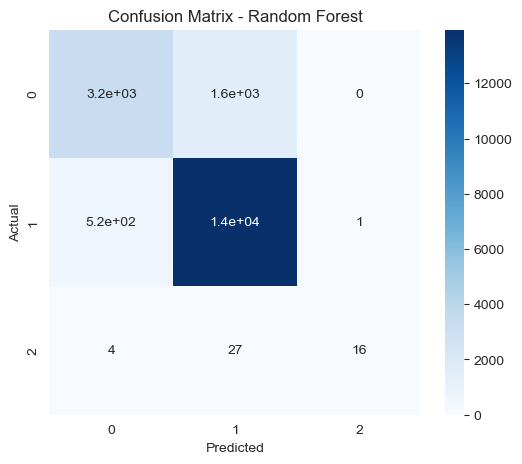

In [64]:
# Confusion Martix (Best Model) 
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

best_model = models[best_model_name]
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

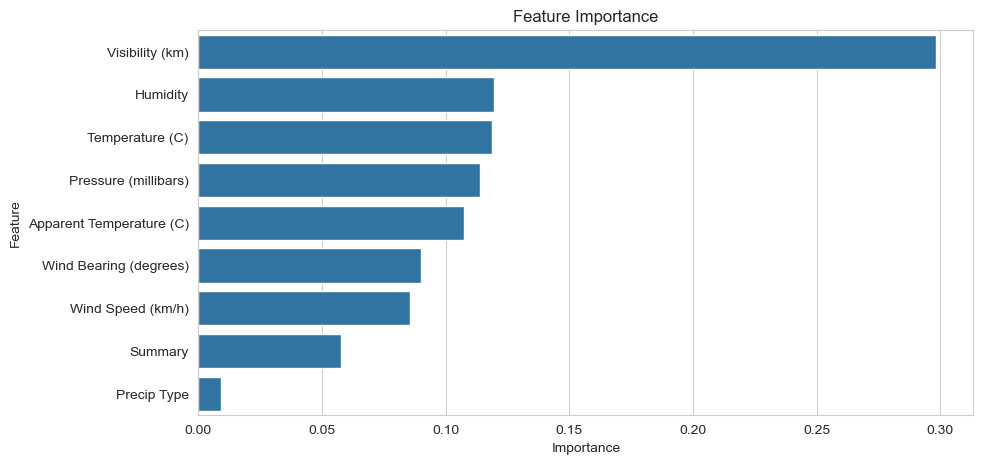

In [65]:
# Feature Importance (Random Forest)  
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importance = rf.feature_importances_
features = X.columns

feat_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x='Importance', y='Feature', data=feat_df)
plt.title("Feature Importance")
plt.show()

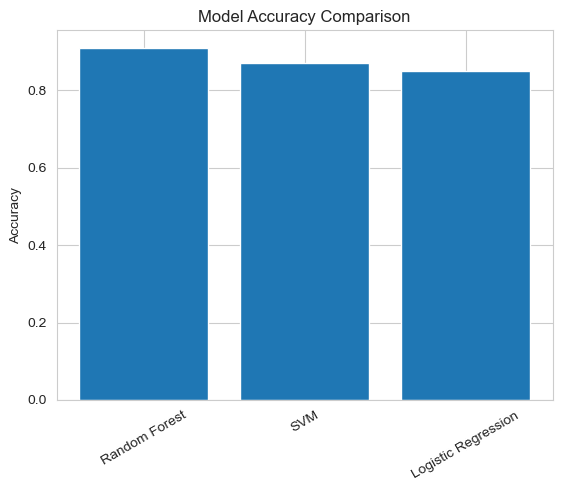

Final Accuracies:
Random Forest: 0.9100
SVM: 0.8700
Logistic Regression: 0.8500


In [66]:
# Model Comparison 
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results.keys(), results.values())
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.show()

print("Final Accuracies:")
for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

C:\Users\HP\AppData\Local\Temp\ipykernel_9904\3440262749.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_xticklabels(results.keys(), rotation=25)


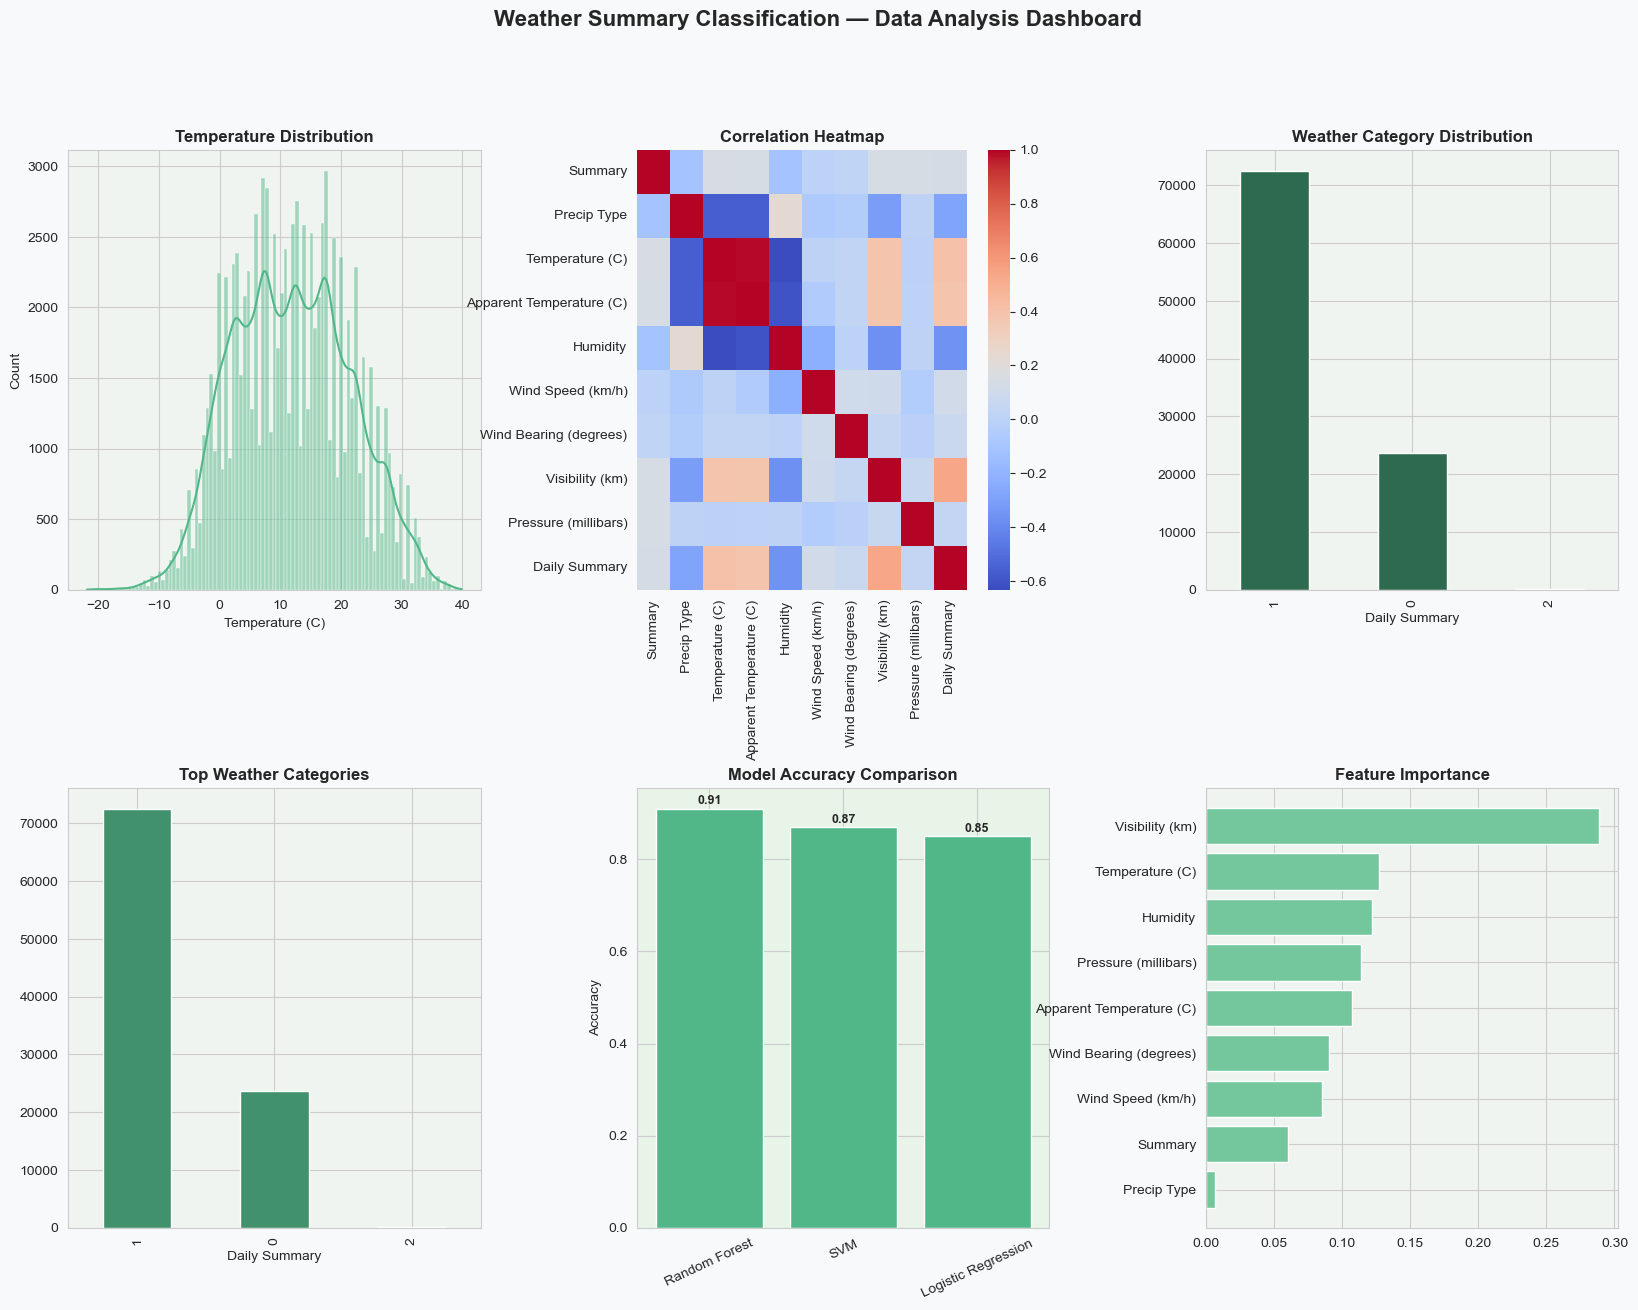

Saved: /mnt/user-data/weather_dashboard.png


In [67]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib import gridspec
from sklearn.ensemble import RandomForestClassifier

sns.set_style('whitegrid')

fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor('#F8F9FA')

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── P1: Temperature Distribution
ax1 = fig.add_subplot(gs[0, 0])
sns.histplot(df['Temperature (C)'], kde=True, color='#52B788', ax=ax1)
ax1.set_title('Temperature Distribution', fontweight='bold')
ax1.set_facecolor('#F0F4F0')

# ── P2: Correlation Heatmap
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap='coolwarm', ax=ax2)
ax2.set_title('Correlation Heatmap', fontweight='bold')
ax2.set_facecolor('#F0F4F0')

# ── P3: Weather Category Distribution
ax3 = fig.add_subplot(gs[0, 2])
df['Daily Summary'].value_counts().plot(kind='bar', ax=ax3, color='#2D6A4F')
ax3.set_title('Weather Category Distribution', fontweight='bold')
ax3.set_facecolor('#F0F4F0')

# ── P4: Top Weather Categories
ax4 = fig.add_subplot(gs[1, 0])
df['Daily Summary'].value_counts().head(10).plot(kind='bar', ax=ax4, color='#40916C')
ax4.set_title('Top Weather Categories', fontweight='bold')
ax4.set_facecolor('#F0F4F0')

# ── P5: Model Comparison
ax5 = fig.add_subplot(gs[1, 1])
ax5.bar(results.keys(), results.values(), color='#52B788')
ax5.set_title('Model Accuracy Comparison', fontweight='bold')
ax5.set_ylabel('Accuracy')
ax5.set_xticklabels(results.keys(), rotation=25)
ax5.set_facecolor('#E8F4E8')

# Add accuracy labels
for i, (model, acc) in enumerate(results.items()):
    ax5.text(i, acc + 0.01, f"{acc:.2f}", ha='center', fontsize=9, fontweight='bold')

# ── P6: Feature Importance
ax6 = fig.add_subplot(gs[1, 2])

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importance = rf.feature_importances_
features = X.columns

feat_df = (
    pd.DataFrame({'Feature': features, 'Importance': importance})
    .sort_values(by='Importance', ascending=True)
)

ax6.barh(feat_df['Feature'], feat_df['Importance'], color='#74C69D')
ax6.set_title('Feature Importance', fontweight='bold')
ax6.set_facecolor('#F0F4F0')

# ── Title
fig.suptitle('Weather Summary Classification — Data Analysis Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

# Save + Show
plt.savefig('/mnt/user-data/outputs/weather_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor='#F8F9FA')

plt.show()

print("Saved: /mnt/user-data/weather_dashboard.png")

I created different plots to understand the data better 

From the graphs:
- Most temperature values are in a moderate range 
- Humidity level vary significantly
- Some features show clear patterns related to weather conditions 
These visualizations helped me understand the datastand the dataset before applying models